# Clustering Analysis - Airlines Dataset

## Objective
To apply K-Means and DBSCAN clustering and compare their performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
excel_file = pd.ExcelFile("EastWestAirlines.xlsx")
print(excel_file.sheet_names)

['Description', 'data']


In [3]:
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [4]:
df = df.drop('ID#', axis=1)
df = df.drop('Award?', axis=1)

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
dtypes: int64(10)
memory usage: 312.6 KB


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000


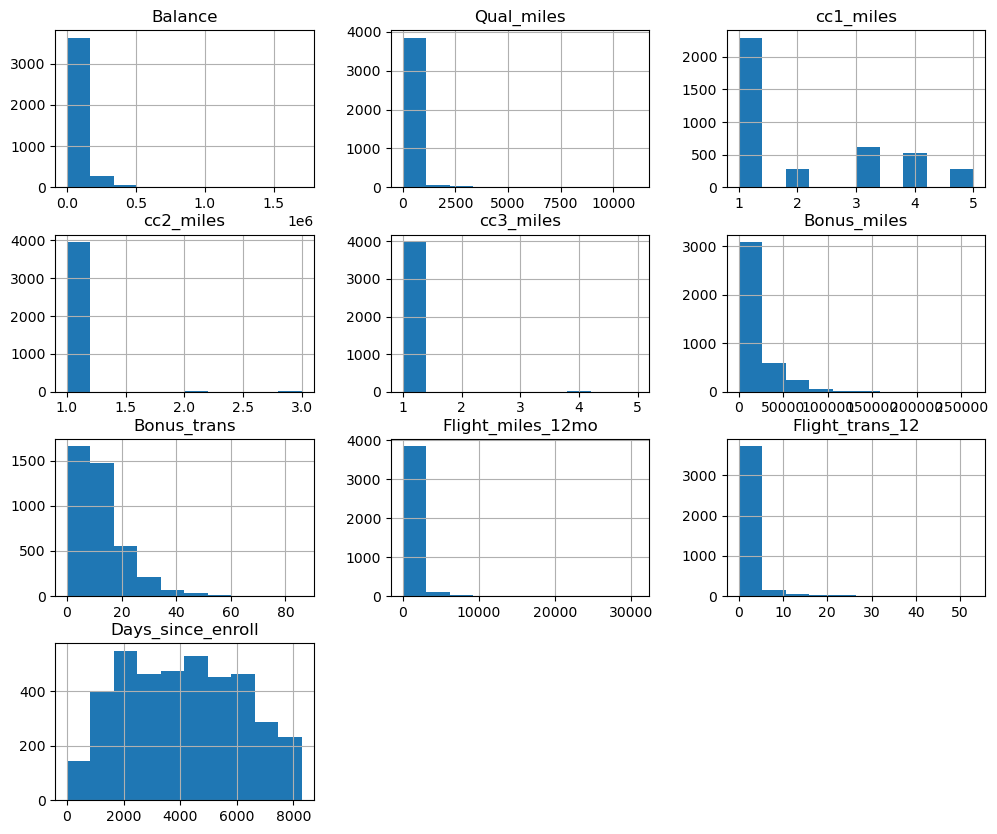

In [6]:
df.hist(figsize=(12,10))
plt.show()

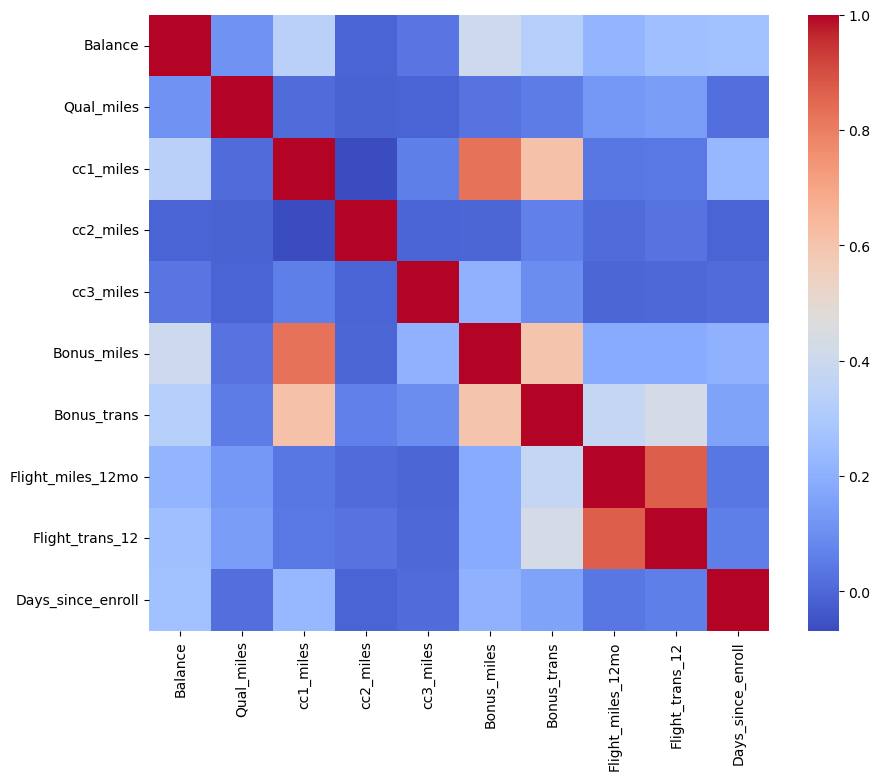

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

## EDA Observations

- Feature scales vary significantly, making standardization essential for clustering.
- Strong correlations exist between:
  - Bonus_miles and Bonus_trans
  - Flight_miles_12mo and Flight_trans_12
- These correlations indicate patterns in customer behavior such as frequent flyers and high-value customers.

These patterns suggest that clustering can effectively segment customers.

In [8]:
X=df
df


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,28143,0,1,1,1,174,1,0,0,7000
1,19244,0,1,1,1,215,2,0,0,6968
2,41354,0,1,1,1,4123,4,0,0,7034
3,14776,0,1,1,1,500,1,0,0,6952
4,97752,0,4,1,1,43300,26,2077,4,6935
...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403
3995,64385,0,1,1,1,981,5,0,0,1395
3996,73597,0,3,1,1,25447,8,0,0,1402
3997,54899,0,1,1,1,500,1,500,1,1401


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

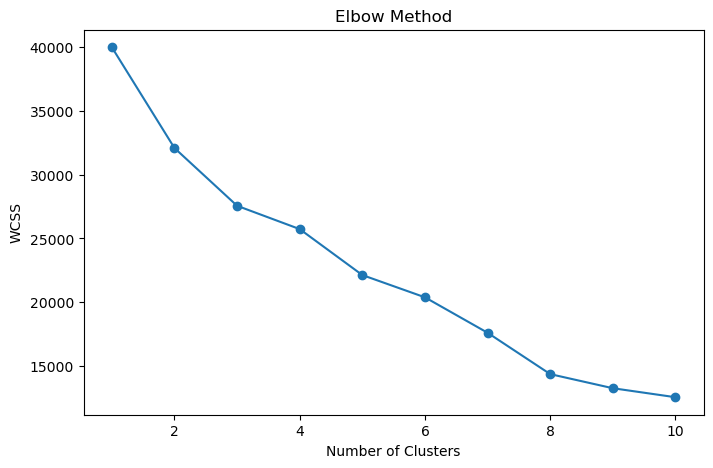

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)

labels_kmeans = kmeans.fit_predict(X_scaled)

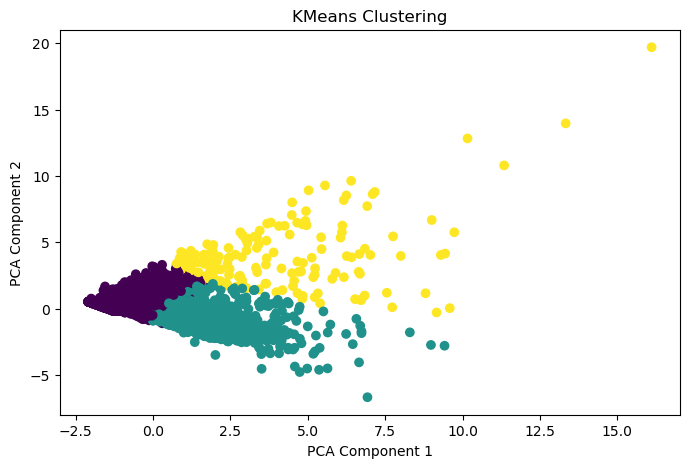

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_vis = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=labels_kmeans,
    cmap='viridis'
)

plt.title("KMeans Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

In [13]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels_kmeans)

print("KMeans Silhouette Score:", score)

KMeans Silhouette Score: 0.33170243934542987


In [14]:
# Add cluster labels to dataframe
df['Cluster'] = labels_kmeans

# Cluster-wise summary
cluster_summary = df.groupby('Cluster').mean()

print(cluster_summary)

               Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
Cluster                                                               
0         42965.737991  112.915840   1.186582   1.019849   1.000397   
1        117679.939440  124.538229   3.710825   1.001514   1.036336   
2        192740.974843  801.031447   2.169811   1.037736   1.000000   

          Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
Cluster                                                                  
0         4443.418023     6.783644         212.489083         0.647479   
1        39594.975776    18.884936         327.908403         0.985617   
2        31850.987421    27.427673        5480.100629        16.100629   

         Days_since_enroll  
Cluster                     
0              3700.755855  
1              4841.000000  
2              4735.559748  


## KMeans Cluster Analysis

- Cluster 0 contains lower activity customers.
- Cluster 1 contains frequent flyers with higher bonus miles and transactions.
- Cluster 2 contains high-value customers with higher balances and award participation.

These customer segments help airlines improve marketing and loyalty strategies.

In [15]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)

labels_db = dbscan.fit_predict(X_scaled)

print("DBSCAN unique labels:", set(labels_db))

DBSCAN unique labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}


In [16]:
score_db = silhouette_score(X_scaled, labels_db)

print("DBSCAN Silhouette Score:", score_db)

DBSCAN Silhouette Score: 0.5676389056959055


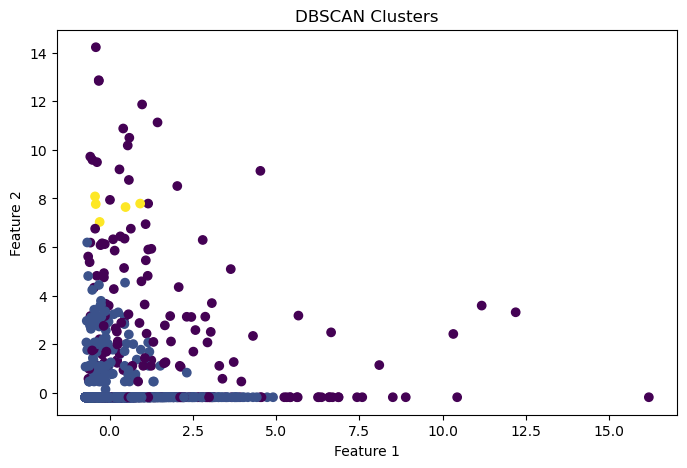

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=labels_db,
    cmap='viridis'
)

plt.title("DBSCAN Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## DBSCAN Cluster Analysis

- DBSCAN identified dense customer groups along with some noise points.
- Unlike KMeans, DBSCAN does not require specifying the number of clusters beforehand.
- It is effective for identifying irregular cluster structures and outliers.

This helps airlines identify unique customer behaviors and unusual patterns.

## Conclusion

- KMeans and DBSCAN clustering algorithms were successfully implemented on the airline dataset.
- KMeans identified meaningful customer groups based on travel behavior and rewards.
- DBSCAN effectively identified dense clusters and noise points.

These insights can help airlines improve customer segmentation, marketing strategies, and loyalty programs.